In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [4]:
DATA_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_network_data.csv"   # change this
df = pd.read_csv(DATA_PATH)

print("Loaded shape:", df.shape)
print(df["Label"].value_counts())

Loaded shape: (6870587, 23)
Label
Benign                      4122352
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [5]:
network_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Tot",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "Fwd Header Len",
    "Bwd Header Len",
    "Init Fwd Win Byts",
    "Init Bwd Win Byts",
    "PSH Flag Cnt",
    "RST Flag Cnt",
    "ACK Flag Cnt",
    "ECE Flag Cnt"
]

missing = [c for c in network_features if c not in df.columns]
if missing:
    print("Missing features skipped:", missing)

network_features = [c for c in network_features if c in df.columns]
print("Using", len(network_features), "features")

Using 22 features


In [6]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Label"]).copy()

# Keep only attacks for Model 2
df_attack = df[df["Label"] != "Benign"].copy()

X = df_attack[network_features].copy()
y = df_attack["Label"].astype(str).copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("Attack-only shape:", X.shape)
print(y.value_counts())

Attack-only shape: (2746934, 22)
Label
DDOS attack-HOIC            686012
DDoS attacks-LOIC-HTTP      576191
DoS attacks-Hulk            461912
Bot                         286191
FTP-BruteForce              193354
SSH-Bruteforce              187589
Infilteration               160639
DoS attacks-SlowHTTPTest    139890
DoS attacks-GoldenEye        41508
DoS attacks-Slowloris        10990
DDOS attack-LOIC-UDP          1730
Brute Force -Web               611
Brute Force -XSS               230
SQL Injection                   87
Name: count, dtype: int64


In [7]:
known_attack_classes = [
    "DDOS attack-HOIC",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-Hulk",
    "Bot",
    "FTP-BruteForce",
    "SSH-Bruteforce",
    "Infilteration",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-GoldenEye",
    "Brute Force -Web"
]

unknown_attack_classes = [
    "DoS attacks-Slowloris",
    "DDOS attack-LOIC-UDP",
    "Brute Force -XSS",
    "SQL Injection"
]

# Filter only selected attacks
selected_classes = known_attack_classes + unknown_attack_classes
mask_selected = y.isin(selected_classes)

X = X[mask_selected]
y = y[mask_selected]

print("Selected attack classes:")
print(y.value_counts())

Selected attack classes:
Label
DDOS attack-HOIC            686012
DDoS attacks-LOIC-HTTP      576191
DoS attacks-Hulk            461912
Bot                         286191
FTP-BruteForce              193354
SSH-Bruteforce              187589
Infilteration               160639
DoS attacks-SlowHTTPTest    139890
DoS attacks-GoldenEye        41508
DoS attacks-Slowloris        10990
DDOS attack-LOIC-UDP          1730
Brute Force -Web               611
Brute Force -XSS               230
SQL Injection                   87
Name: count, dtype: int64


In [8]:
X_known = X[y.isin(known_attack_classes)]
y_known_labels = y[y.isin(known_attack_classes)]

X_unknown = X[y.isin(unknown_attack_classes)]
y_unknown_labels = y[y.isin(unknown_attack_classes)]

print("Known attacks:", X_known.shape)
print("Unknown attacks:", X_unknown.shape)

Known attacks: (2733897, 22)
Unknown attacks: (13037, 22)


In [9]:
X_known_train_raw, X_known_val_raw = train_test_split(
    X_known,
    test_size=0.2,
    random_state=42,
    stratify=y_known_labels
)

print("Known train:", X_known_train_raw.shape)
print("Known val:", X_known_val_raw.shape)

Known train: (2187117, 22)
Known val: (546780, 22)


In [10]:
scaler = StandardScaler()

X_known_train = scaler.fit_transform(X_known_train_raw)
X_known_val = scaler.transform(X_known_val_raw)
X_unknown_scaled = scaler.transform(X_unknown)

print("Scaled shapes:")
print("Known train:", X_known_train.shape)
print("Known val:", X_known_val.shape)
print("Unknown:", X_unknown_scaled.shape)

Scaled shapes:
Known train: (2187117, 22)
Known val: (546780, 22)
Unknown: (13037, 22)


In [11]:
def evaluate_known_unknown(
    known_scores,
    unknown_scores,
    threshold,
    model_name="Model"
):
    # 0 = known, 1 = unknown
    y_known_true = np.zeros(len(known_scores), dtype=int)
    y_unknown_true = np.ones(len(unknown_scores), dtype=int)

    y_known_pred = (known_scores > threshold).astype(int)
    y_unknown_pred = (unknown_scores > threshold).astype(int)

    y_true = np.concatenate([y_known_true, y_unknown_true])
    y_pred = np.concatenate([y_known_pred, y_unknown_pred])
    y_scores = np.concatenate([known_scores, unknown_scores])

    print(f"\n===== {model_name} =====")
    print("Threshold:", threshold)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print("Confusion Matrix [[TN, FP], [FN, TP]]:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Known", "Unknown"]
    )
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} - Known vs Unknown")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Known", "Unknown"]))

    auc = roc_auc_score(y_true, y_scores)
    print("ROC-AUC:", auc)

    return y_true, y_pred

In [12]:
iso_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_known_train)

joblib.dump(iso_model, "model2_isolation_forest.joblib")
print("Isolation Forest trained.")

Isolation Forest trained.


In [13]:
# Higher original score = more inlier/known
iso_known_val_score_raw = iso_model.decision_function(X_known_val)
iso_unknown_score_raw = iso_model.decision_function(X_unknown_scaled)

# Convert so higher = more unknown/anomalous
iso_known_val_score = -iso_known_val_score_raw
iso_unknown_score = -iso_unknown_score_raw

print("Known score stats:")
print(pd.Series(iso_known_val_score).describe())

print("\nUnknown score stats:")
print(pd.Series(iso_unknown_score).describe())

Known score stats:
count    546780.000000
mean         -0.088511
std           0.070812
min          -0.164009
25%          -0.150172
50%          -0.096809
75%          -0.059150
max           0.261963
dtype: float64

Unknown score stats:
count    13037.000000
mean         0.131654
std          0.099013
min         -0.162084
25%         -0.008608
50%          0.188336
75%          0.193042
max          0.210584
dtype: float64



--- Isolation Forest percentile 90 ---

===== Isolation Forest (p=90) =====
Threshold: 0.019115510211286546
Confusion Matrix [[TN, FP], [FN, TP]]:
[[494963  51817]
 [  3543   9494]]


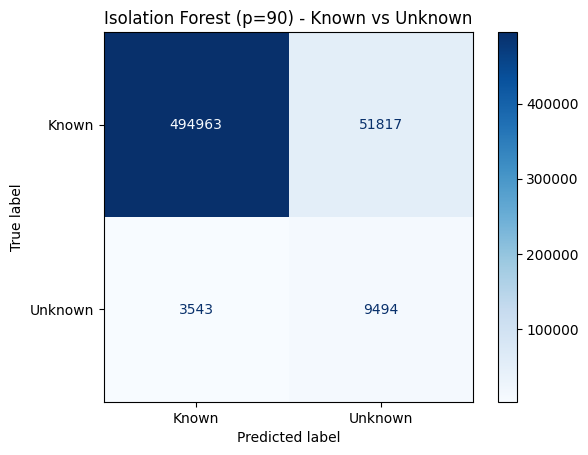


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.91      0.95    546780
     Unknown       0.15      0.73      0.26     13037

    accuracy                           0.90    559817
   macro avg       0.57      0.82      0.60    559817
weighted avg       0.97      0.90      0.93    559817

ROC-AUC: 0.9403991297108243

--- Isolation Forest percentile 92 ---

===== Isolation Forest (p=92) =====
Threshold: 0.030559537883217747
Confusion Matrix [[TN, FP], [FN, TP]]:
[[503106  43674]
 [  3543   9494]]


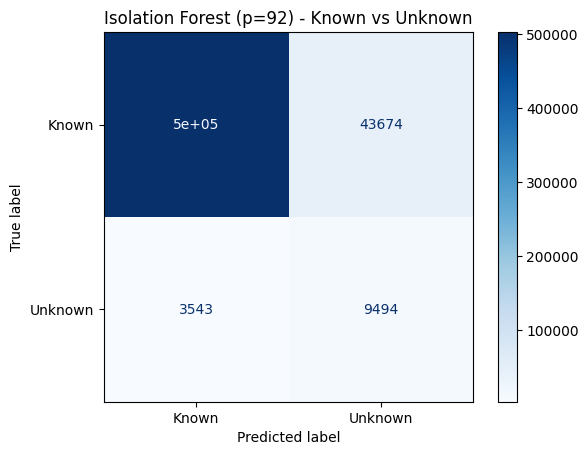


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.92      0.96    546780
     Unknown       0.18      0.73      0.29     13037

    accuracy                           0.92    559817
   macro avg       0.59      0.82      0.62    559817
weighted avg       0.97      0.92      0.94    559817

ROC-AUC: 0.9403991297108243

--- Isolation Forest percentile 95 ---

===== Isolation Forest (p=95) =====
Threshold: 0.043891124884013734
Confusion Matrix [[TN, FP], [FN, TP]]:
[[519441  27339]
 [  3571   9466]]


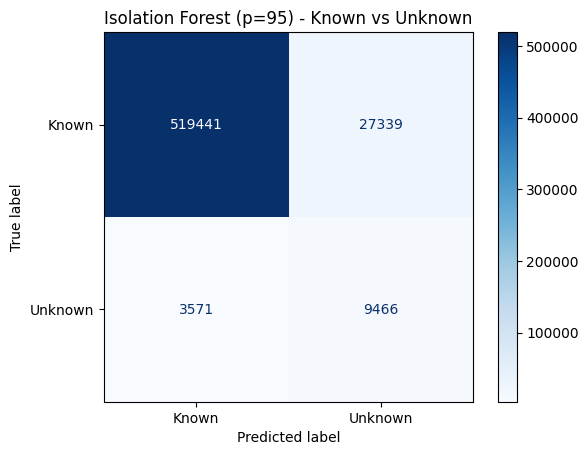


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.95      0.97    546780
     Unknown       0.26      0.73      0.38     13037

    accuracy                           0.94    559817
   macro avg       0.63      0.84      0.68    559817
weighted avg       0.98      0.94      0.96    559817

ROC-AUC: 0.9403991297108243

--- Isolation Forest percentile 97 ---

===== Isolation Forest (p=97) =====
Threshold: 0.06254825053036972
Confusion Matrix [[TN, FP], [FN, TP]]:
[[530379  16401]
 [  3582   9455]]


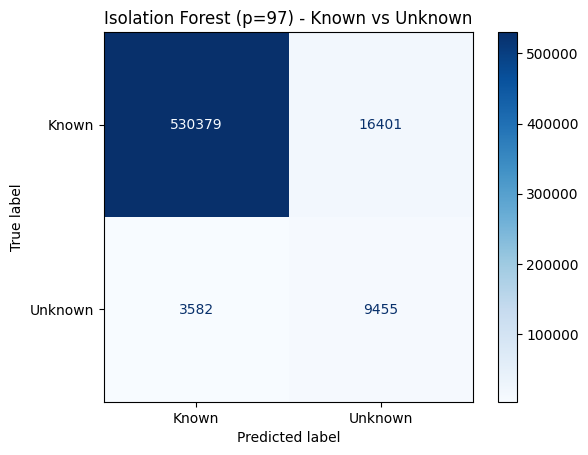


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.97      0.98    546780
     Unknown       0.37      0.73      0.49     13037

    accuracy                           0.96    559817
   macro avg       0.68      0.85      0.73    559817
weighted avg       0.98      0.96      0.97    559817

ROC-AUC: 0.9403991297108243

--- Isolation Forest percentile 99 ---

===== Isolation Forest (p=99) =====
Threshold: 0.13812437459746119
Confusion Matrix [[TN, FP], [FN, TP]]:
[[541315   5465]
 [  3767   9270]]


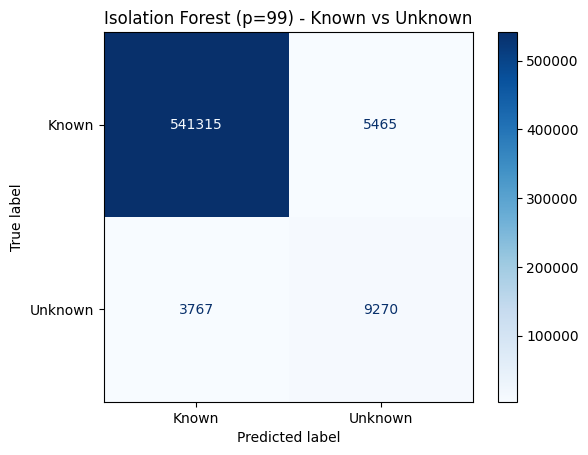


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.99      0.99    546780
     Unknown       0.63      0.71      0.67     13037

    accuracy                           0.98    559817
   macro avg       0.81      0.85      0.83    559817
weighted avg       0.98      0.98      0.98    559817

ROC-AUC: 0.9403991297108243


In [14]:
for p in [90, 92, 95, 97, 99]:
    thr = np.percentile(iso_known_val_score, p)

    print(f"\n--- Isolation Forest percentile {p} ---")
    evaluate_known_unknown(
        iso_known_val_score,
        iso_unknown_score,
        threshold=thr,
        model_name=f"Isolation Forest (p={p})"
    )

In [15]:
# One-Class SVM can be slow; subsample if needed
MAX_OCSVM_TRAIN = 200000

if X_known_train.shape[0] > MAX_OCSVM_TRAIN:
    rng = np.random.RandomState(42)
    idx = rng.choice(X_known_train.shape[0], size=MAX_OCSVM_TRAIN, replace=False)
    X_known_train_ocsvm = X_known_train[idx]
    print("Subsampled OCSVM training shape:", X_known_train_ocsvm.shape)
else:
    X_known_train_ocsvm = X_known_train

ocsvm_model = OneClassSVM(
    kernel="rbf",
    nu=0.1,         # try 0.05, 0.1, 0.2
    gamma="scale"
)

ocsvm_model.fit(X_known_train_ocsvm)

joblib.dump(ocsvm_model, "model2_oneclasssvm.joblib")
print("One-Class SVM trained.")

Subsampled OCSVM training shape: (200000, 22)
One-Class SVM trained.


In [16]:
ocsvm_known_val_score_raw = ocsvm_model.decision_function(X_known_val)
ocsvm_unknown_score_raw = ocsvm_model.decision_function(X_unknown_scaled)

# higher = more unknown
ocsvm_known_val_score = -ocsvm_known_val_score_raw
ocsvm_unknown_score = -ocsvm_unknown_score_raw

print("Known score stats:")
print(pd.Series(ocsvm_known_val_score).describe())

print("\nUnknown score stats:")
print(pd.Series(ocsvm_unknown_score).describe())

Known score stats:
count    546780.000000
mean         16.409952
std         380.749765
min        -465.236146
25%         -64.938099
50%         -11.685915
75%          -0.087364
max        2998.179652
dtype: float64

Unknown score stats:
count    13037.000000
mean      2009.355874
std       1371.905348
min       -432.221269
25%        624.330176
50%       2762.877328
75%       2936.483734
max       2998.179652
dtype: float64



--- One-Class SVM percentile 90 ---

===== One-Class SVM (p=90) =====
Threshold: 0.00010804394014485297
Confusion Matrix [[TN, FP], [FN, TP]]:
[[498286  48494]
 [  2885  10152]]


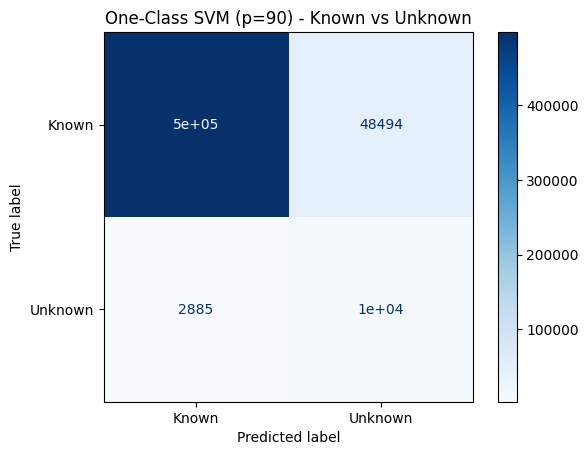


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.91      0.95    546780
     Unknown       0.17      0.78      0.28     13037

    accuracy                           0.91    559817
   macro avg       0.58      0.85      0.62    559817
weighted avg       0.98      0.91      0.94    559817

ROC-AUC: 0.7904612075696633

--- One-Class SVM percentile 92 ---

===== One-Class SVM (p=92) =====
Threshold: 0.01512632543883219
Confusion Matrix [[TN, FP], [FN, TP]]:
[[503037  43743]
 [  2885  10152]]


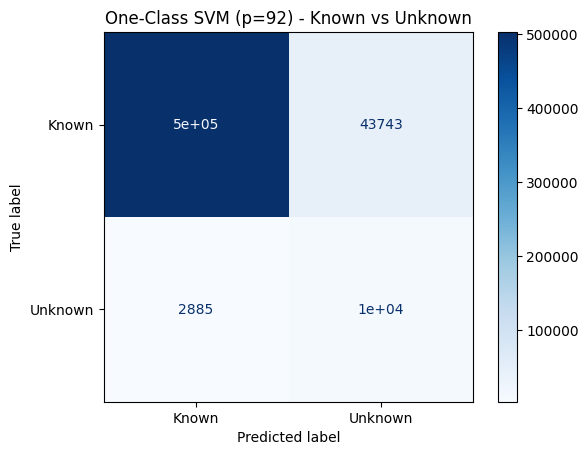


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.92      0.96    546780
     Unknown       0.19      0.78      0.30     13037

    accuracy                           0.92    559817
   macro avg       0.59      0.85      0.63    559817
weighted avg       0.98      0.92      0.94    559817

ROC-AUC: 0.7904612075696633

--- One-Class SVM percentile 95 ---

===== One-Class SVM (p=95) =====
Threshold: 2.9346132518056542
Confusion Matrix [[TN, FP], [FN, TP]]:
[[519441  27339]
 [  2886  10151]]


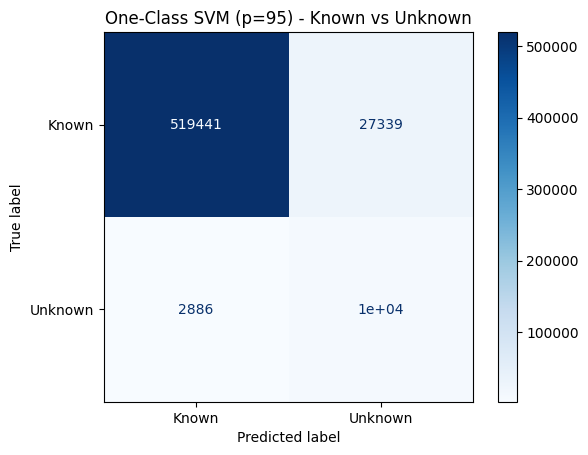


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.95      0.97    546780
     Unknown       0.27      0.78      0.40     13037

    accuracy                           0.95    559817
   macro avg       0.63      0.86      0.69    559817
weighted avg       0.98      0.95      0.96    559817

ROC-AUC: 0.7904612075696633

--- One-Class SVM percentile 97 ---

===== One-Class SVM (p=97) =====
Threshold: 245.42299158135842
Confusion Matrix [[TN, FP], [FN, TP]]:
[[530376  16404]
 [  2953  10084]]


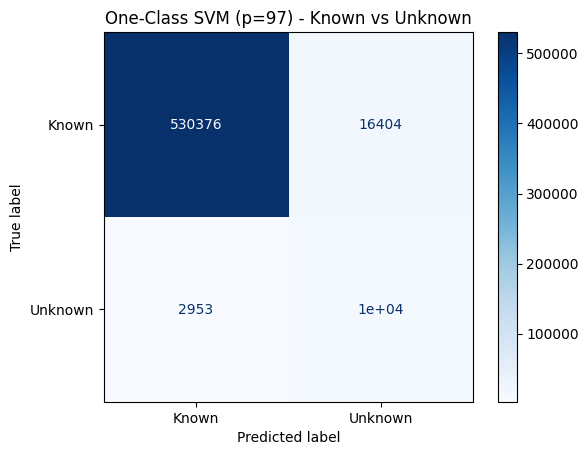


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.97      0.98    546780
     Unknown       0.38      0.77      0.51     13037

    accuracy                           0.97    559817
   macro avg       0.69      0.87      0.75    559817
weighted avg       0.98      0.97      0.97    559817

ROC-AUC: 0.7904612075696633

--- One-Class SVM percentile 99 ---

===== One-Class SVM (p=99) =====
Threshold: 2489.1749812050234
Confusion Matrix [[TN, FP], [FN, TP]]:
[[541312   5468]
 [  3749   9288]]


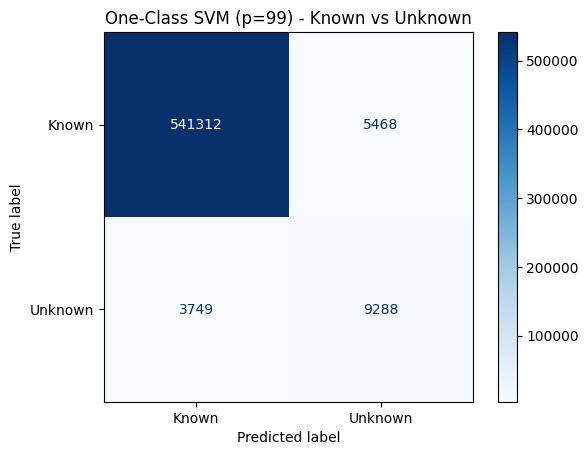


Classification Report:
              precision    recall  f1-score   support

       Known       0.99      0.99      0.99    546780
     Unknown       0.63      0.71      0.67     13037

    accuracy                           0.98    559817
   macro avg       0.81      0.85      0.83    559817
weighted avg       0.98      0.98      0.98    559817

ROC-AUC: 0.7904612075696633


In [17]:
for p in [90, 92, 95, 97, 99]:
    thr = np.percentile(ocsvm_known_val_score, p)

    print(f"\n--- One-Class SVM percentile {p} ---")
    evaluate_known_unknown(
        ocsvm_known_val_score,
        ocsvm_unknown_score,
        threshold=thr,
        model_name=f"One-Class SVM (p={p})"
    )

In [18]:
def per_unknown_attack_detection_rate(
    X_unknown_raw,
    y_unknown_labels,
    scaler,
    score_function,
    threshold
):
    rows = []

    for lab in sorted(y_unknown_labels.unique()):
        X_lab = X_unknown_raw[y_unknown_labels == lab]
        X_lab_scaled = scaler.transform(X_lab)

        scores = score_function(X_lab_scaled)
        preds = (scores > threshold).astype(int)   # 1 = unknown

        detection_rate = preds.mean()
        rows.append((lab, len(X_lab), detection_rate))

    report_df = pd.DataFrame(
        rows,
        columns=["Unknown Attack Label", "Samples", "Detection Rate"]
    ).sort_values("Detection Rate", ascending=False)

    return report_df

In [19]:
best_iso_threshold = np.percentile(iso_known_val_score, 95)

iso_unknown_report = per_unknown_attack_detection_rate(
    X_unknown,
    y_unknown_labels,
    scaler,
    score_function=lambda x: -iso_model.decision_function(x),
    threshold=best_iso_threshold
)

print("Isolation Forest - per unknown attack detection:")
print(iso_unknown_report)

Isolation Forest - per unknown attack detection:
    Unknown Attack Label  Samples  Detection Rate
1   DDOS attack-LOIC-UDP     1730        1.000000
2  DoS attacks-Slowloris    10990        0.692539
0       Brute Force -XSS      230        0.495652
3          SQL Injection       87        0.126437


In [20]:
best_ocsvm_threshold = np.percentile(ocsvm_known_val_score, 95)

ocsvm_unknown_report = per_unknown_attack_detection_rate(
    X_unknown,
    y_unknown_labels,
    scaler,
    score_function=lambda x: -ocsvm_model.decision_function(x),
    threshold=best_ocsvm_threshold
)

print("One-Class SVM - per unknown attack detection:")
print(ocsvm_unknown_report)

One-Class SVM - per unknown attack detection:
    Unknown Attack Label  Samples  Detection Rate
1   DDOS attack-LOIC-UDP     1730        1.000000
2  DoS attacks-Slowloris    10990        0.755232
0       Brute Force -XSS      230        0.495652
3          SQL Injection       87        0.080460


In [21]:
comparison_rows = []

for model_name, known_scores, unknown_scores in [
    ("Isolation Forest", iso_known_val_score, iso_unknown_score),
    ("One-Class SVM", ocsvm_known_val_score, ocsvm_unknown_score),
]:
    thr = np.percentile(known_scores, 95)

    y_known_true = np.zeros(len(known_scores), dtype=int)
    y_unknown_true = np.ones(len(unknown_scores), dtype=int)

    y_known_pred = (known_scores > thr).astype(int)
    y_unknown_pred = (unknown_scores > thr).astype(int)

    y_true = np.concatenate([y_known_true, y_unknown_true])
    y_pred = np.concatenate([y_known_pred, y_unknown_pred])
    y_scores = np.concatenate([known_scores, unknown_scores])

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    known_recall = tn / (tn + fp + 1e-12)
    unknown_recall = tp / (tp + fn + 1e-12)
    unknown_precision = tp / (tp + fp + 1e-12)
    auc = roc_auc_score(y_true, y_scores)

    comparison_rows.append([
        model_name,
        known_recall,
        unknown_recall,
        unknown_precision,
        auc
    ])

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=[
        "Model",
        "Known Recall",
        "Unknown Recall",
        "Unknown Precision",
        "ROC-AUC"
    ]
)

print(comparison_df)

              Model  Known Recall  Unknown Recall  Unknown Precision   ROC-AUC
0  Isolation Forest          0.95        0.726087           0.257193  0.940399
1     One-Class SVM          0.95        0.778630           0.270766  0.790461
